# Starter Notebook: Phishing Websites

This dataset contains handcrafted URL/domain/page features for detecting phishing websites. The task is binary classification: distinguish phishing websites from legitimate websites.


## General Workflow

Use this notebook as a starting point. Your goal is to reason about the dataset, build multiple supervised learning models, and justify your final choice.

Recommended workflow:

1. Load and inspect the dataset.
2. Identify the target variable and the feature matrix.
3. Explore the data with summary statistics and visualizations.
4. Prepare the data for modeling.
5. Try feature selection.
6. Optionally try feature extraction or basis function expansion.
7. Train several appropriate supervised learning models.
8. Evaluate and compare the models using suitable metrics.
9. Summarize which model worked best and why.


## Dataset-Specific Notes

Target column: `Result`

Original labels:

- `-1`: phishing
- `1`: legitimate

For evaluation, encode phishing as the positive class (`1`) and legitimate as the negative class (`0`). In cybersecurity, false negatives are important because they are phishing websites predicted as legitimate.


## 1. Imports

Import the libraries you need for data analysis, visualization, preprocessing, modeling, and evaluation.


In [56]:
# TODO: import libraries

RANDOM_STATE = 42

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

## 2. Loading the Data

Load the prepared single-file CSV version of the Phishing Websites dataset. The original ARFF file has already been converted to a normal CSV with feature names in the first row.


In [57]:
# TODO: set DATA_PATH to the location of your downloaded dataset.csv file
# TODO: load the CSV file into a DataFrame
# Example: df = pd.read_csv(DATA_PATH)

# Постави ја точната патека до фајлот во Colab
DATA_PATH = "/content/dataset_2_phishing_websites.csv"

df = pd.read_csv(DATA_PATH)

print("Првите 5 редови од податоците:")
df.head()


Првите 5 редови од податоците:


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## 3. Initial Inspection

Inspect the dataset shape, feature types, missing values, target distribution, and any dataset-specific issues.


In [58]:
# Анализа на податоците
target_col = 'Result'

print("=== СТАТИСТИЧКИ ПРЕГЛЕД ===")
display(df.describe())

print("\n=== MISSING VALUES ПО КОЛОНИ ===")
print(df.isnull().sum())

# да провериме по колку примероци има од секоја класа
print("\n=== ДИСТРИБУЦИЈА НА КЛАСИТЕ ===")
print(df[target_col].value_counts())

# датасетот нема аномалии како екстремна небалансираност или огромни празнини кои бараат дополнителни алгоритми за чистење


=== СТАТИСТИЧКИ ПРЕГЛЕД ===


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



=== MISSING VALUES ПО КОЛОНИ ===
having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistic

## 4. Visualization

Create visualizations that explain the dataset and the modeling challenge. Choose plots that are relevant for this specific problem.


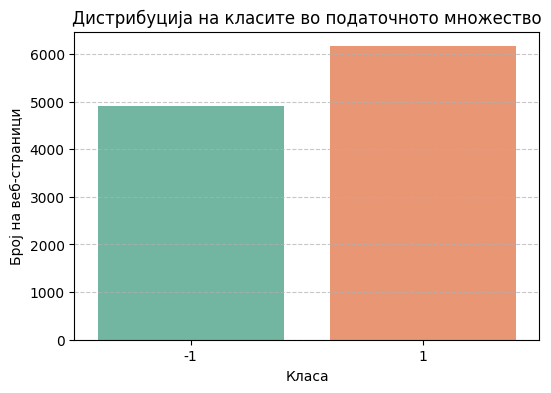

In [59]:
# TODO: create visualizations
# Визуелизација на дистрибуција
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, hue=target_col, data=df, palette='Set2', legend=False)
plt.title('Дистрибуција на класите во податочното множество')
plt.xlabel('Класа')
plt.ylabel('Број на веб-страници')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

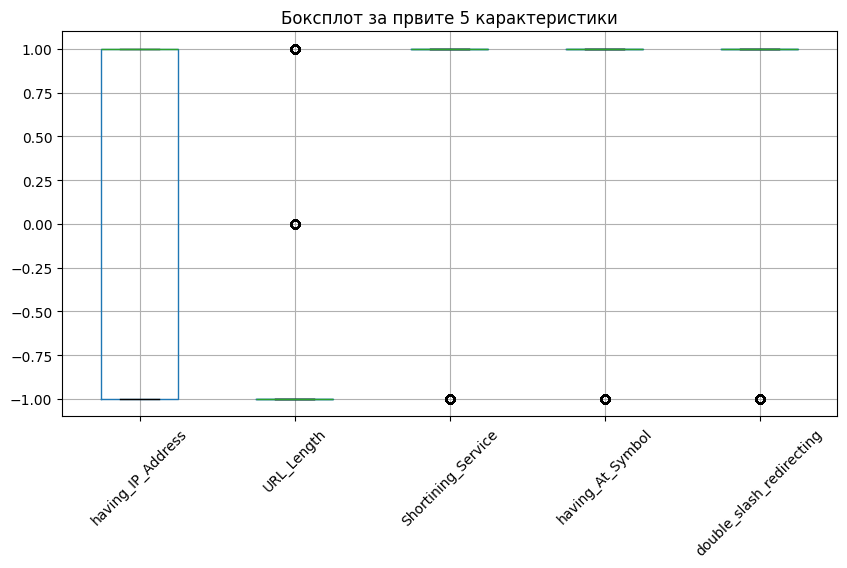

In [60]:
# Боксплот за првите 5 карактеристики
fig = plt.figure(figsize=(10, 5))
df.iloc[:, :5].boxplot()
plt.title("Боксплот за првите 5 карактеристики")
plt.xticks(rotation=45)
plt.show()

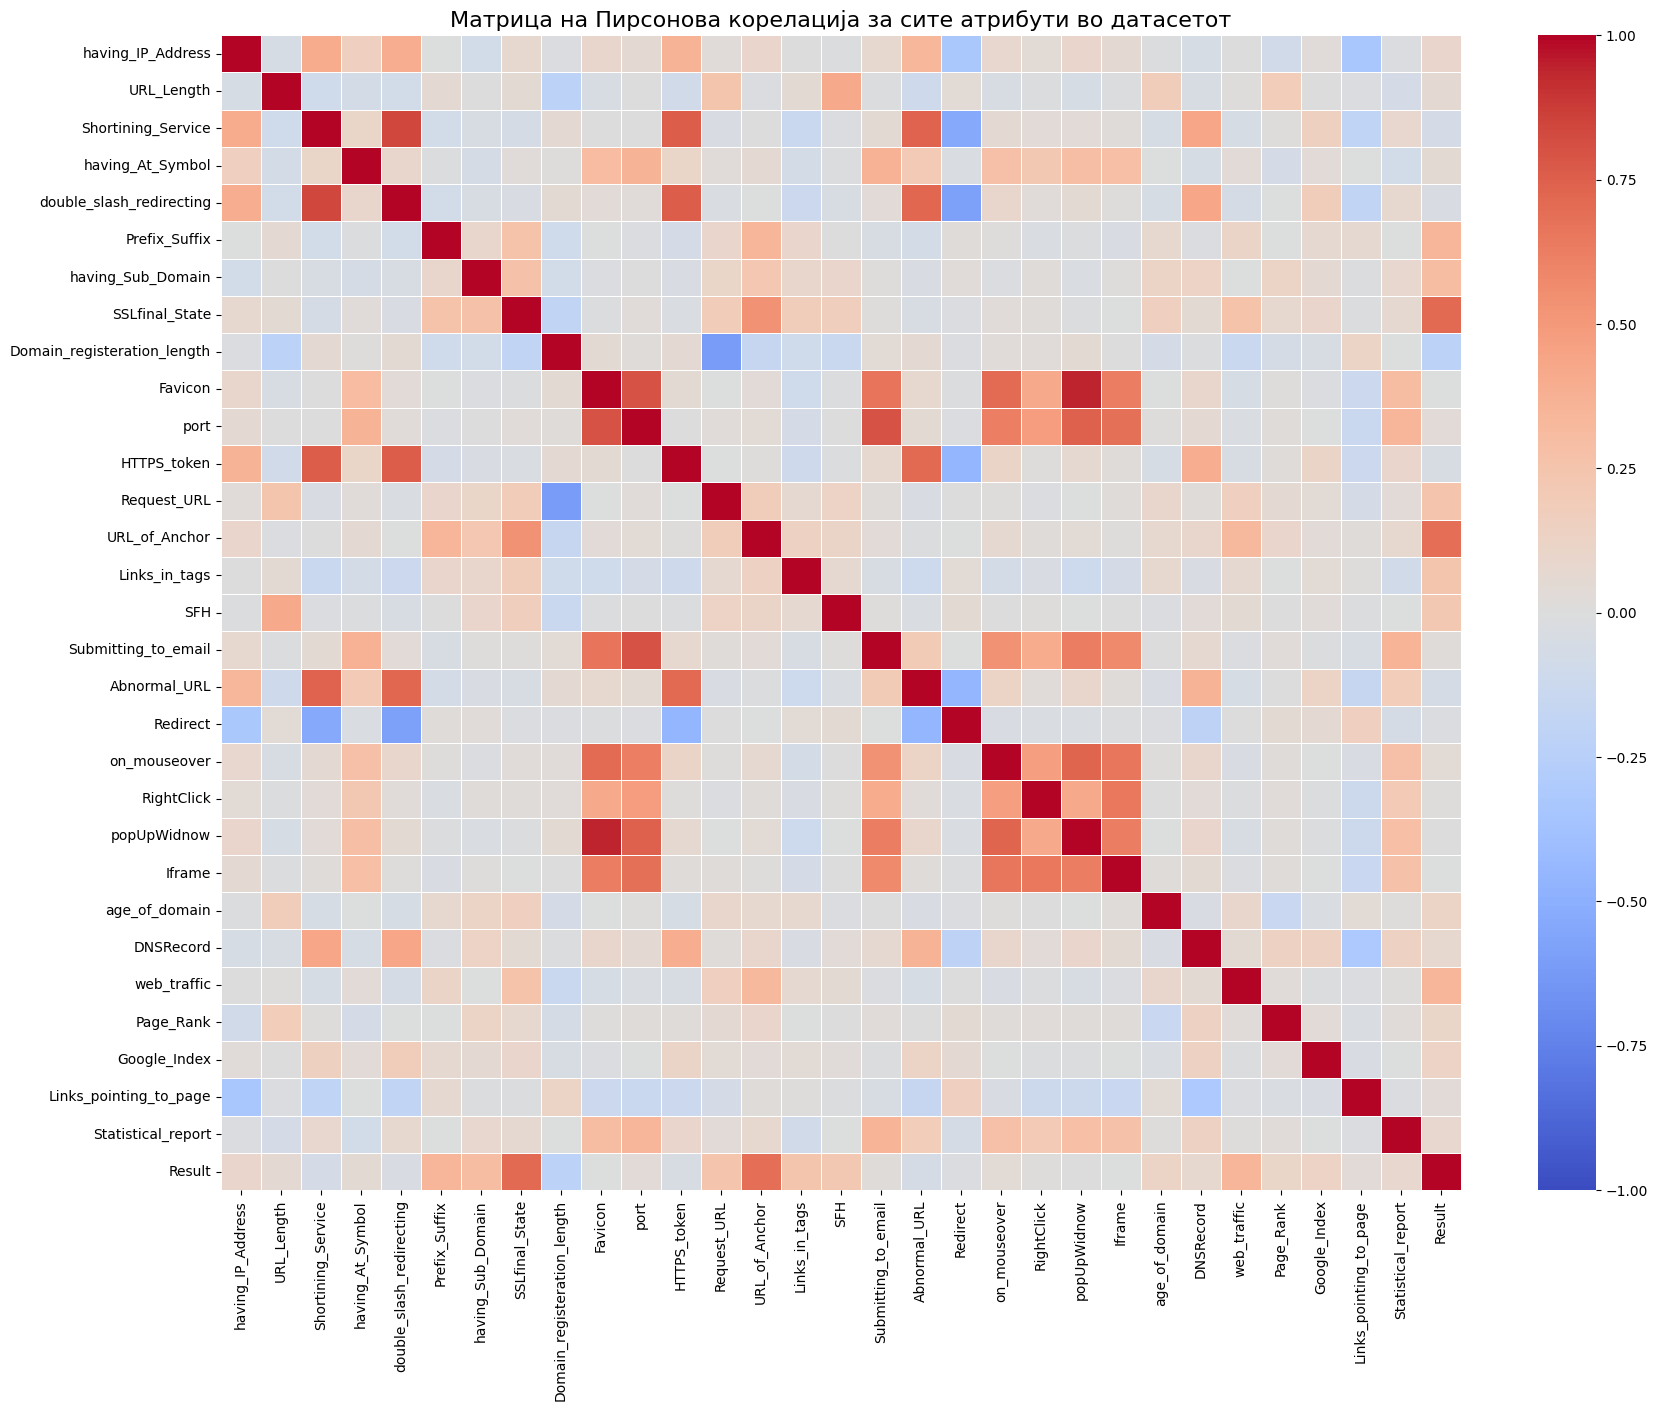

In [61]:
# Матрица на Пирсонова корелација за сите атрибути
plt.figure(figsize=(20, 15))

# Пресметка на корелација за цел датасет
correlation_matrix = df.corr(method='pearson')

# Цртаме без бројки (annot=False) за да биде прегледно и читливо
sns.heatmap(correlation_matrix,
            cmap='coolwarm',
            annot=False,       # ВАЖНО: Исклучено за да нема магли од бројки
            linewidths=0.5,     # Тенки линии меѓу квадратчињата за структура
            vmin=-1, vmax=1)    # Скала од -1 до 1

plt.title('Матрица на Пирсонова корелација за сите атрибути во датасетот', fontsize=16)
plt.xticks(rotation=90, fontsize=10) # Ги ротираме имињата на x-оската
plt.yticks(fontsize=10)
plt.show()

In [62]:
target_col = df.columns[-1]  # Автоматски ја зема последната колона

# 3. Ги земаме корелациите само за таргет колоната
target_correlations = correlation_matrix[target_col]

# 4. Сортирање по апсолутна вредност (од највисока кон најниска)
# Го исклучуваме самиот таргет (бидејќи корелацијата на Result со Result е секогаш 1.0)
top_features_all = target_correlations.abs().sort_values(ascending=False).drop(target_col)

# 5. Извлекуваме топ 4 најкорелирани атрибути како листа
top_4_features = list(top_features_all.head(4).index)

# Печатење на резултатот
print("ТОП 4 НАЈКОРЕЛИРАНИ АТРИБУТИ СО ЦЕЛТА:")
for rank, col_name in enumerate(top_4_features, 1):
    original_corr = target_correlations[col_name]
    print(f"{rank}. Атрибут: '{col_name}' | Корелација: {original_corr:.4f}")

ТОП 4 НАЈКОРЕЛИРАНИ АТРИБУТИ СО ЦЕЛТА:
1. Атрибут: 'SSLfinal_State' | Корелација: 0.7147
2. Атрибут: 'URL_of_Anchor' | Корелација: 0.6929
3. Атрибут: 'Prefix_Suffix' | Корелација: 0.3486
4. Атрибут: 'web_traffic' | Корелација: 0.3461


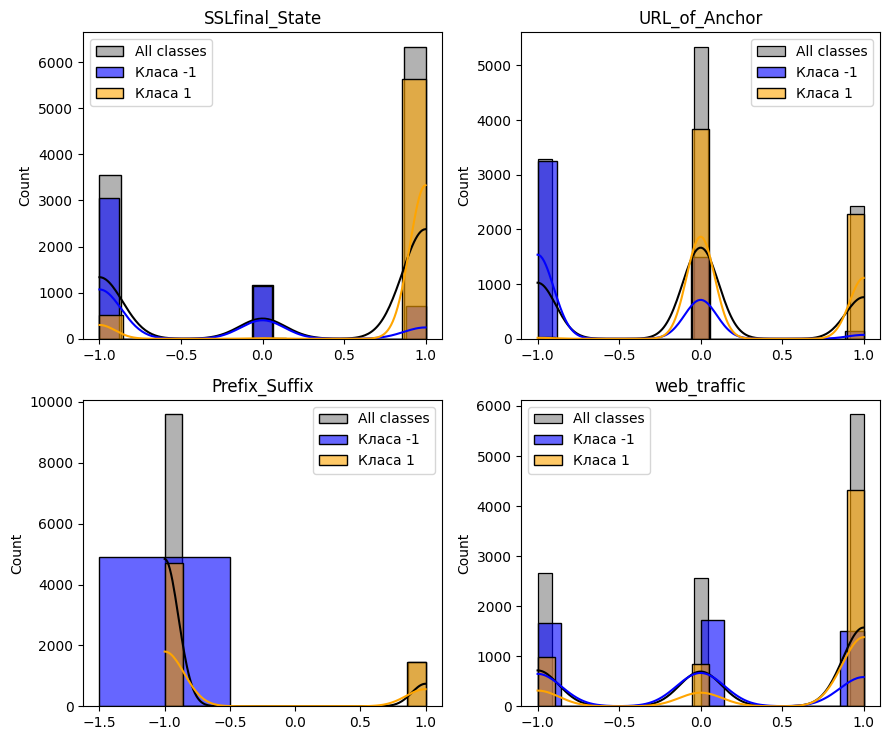

In [63]:
# Го користиме веќе најдениот резултат за топ_4_features од претходниот блок
X_sample = df[top_4_features].values  # Ги земаме вредностите само за тие 4 карактеристики
y_sample = df.iloc[:, -1].values  # Таргет колоната
feature_names_sample = top_4_features # Имињата на најкорелираните карактеристики за наслов
target_names_sample = ['Легитимен', 'Phishing']

colors = ['blue', 'orange'] # бидејќи имаме 2 класи (легитимни и лажни)
number_of_features = 4
number_of_classes = 2

fig = plt.figure(figsize=(9, 7.5))

for feature in range(number_of_features):
    ax = plt.subplot(2, 2, feature + 1)
    plt.title(feature_names_sample[feature])

    # Хистограм за сите класи заедно
    sns.histplot(X_sample[:, feature], color='black', label='All classes', kde=True, stat="count", alpha=0.3)

    # Хистограм за секоја класа посебно
    for Class in range(number_of_classes):
        unique_classes = np.unique(y_sample)
        current_class_val = unique_classes[Class]

        sns.histplot(X_sample[y_sample == current_class_val, feature],
                     color=colors[Class],
                     label=f"Класа {current_class_val}",
                     kde=True,
                     stat="count",
                     alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

In [64]:
# Избираме 3 карактеристики + последната таргет колона
# target_col = df.columns[-1]
# selected_cols = list(df.columns[:3]) + [target_col]

# # Извршување на pairplot со дијагонални хистограми
# sns.pairplot(df[selected_cols], hue=target_col, diag_kind="hist", palette="Set1")
# plt.suptitle("Pairplot за селектирани карактеристики", y=1.02)
# plt.show()

Функцијата pairplot беше исфрлена од анализата бидејќи примарно користи Scatter plots, кои се наменети за континуирани променливи. Со оглед на тоа што нашиот датасет содржи дискретни/категорични карактеристики кодирани со $\{-1, 0, 1\}$, точките се преклопуваат на фиксни координати (overplotting), со што графиконот ја губи својата информативна вредност. Наместо тоа, за правилен приказ на дистрибуцијата и релациите беа искористени Хистограми и Матрица на корелација

## 5. Preprocessing

Prepare `X` and `y`, encode labels if needed, split the data, and decide what preprocessing each model requires.


In [65]:
# TODO: create X/y, split data, and define preprocessing pipelines

# X ги содржи сите колони освен последната
X = df.iloc[:, :-1].values

# y ја содржи само последната колона (таргетот)
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Оригинално: Phishing = -1, Legitimate = 1
# Ново: Phishing (-1) станува Позитивна класа (1), а Legitimate (1) станува Негативна класа (0)
y_train = np.where(y_train == -1, 1, 0)
y_test = np.where(y_test == -1, 1, 0)

print(f"За тренирање (X_train): {X_train.shape}")
print(f"За тестирање (X_test): {X_test.shape}")

# Креирање на скалер кој ги префрла вредностите во опсег [0, 1]
scaler = MinMaxScaler() # Naive Bayes, KNN, SVC, LDA, QDA, Log. Reg., Neural Network

# Прилагодување и трансформација податоците
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

За тренирање (X_train): (8844, 30)
За тестирање (X_test): (2211, 30)


## 6. Feature Selection

Try at least one feature selection method. Inspect or discuss the selected features.


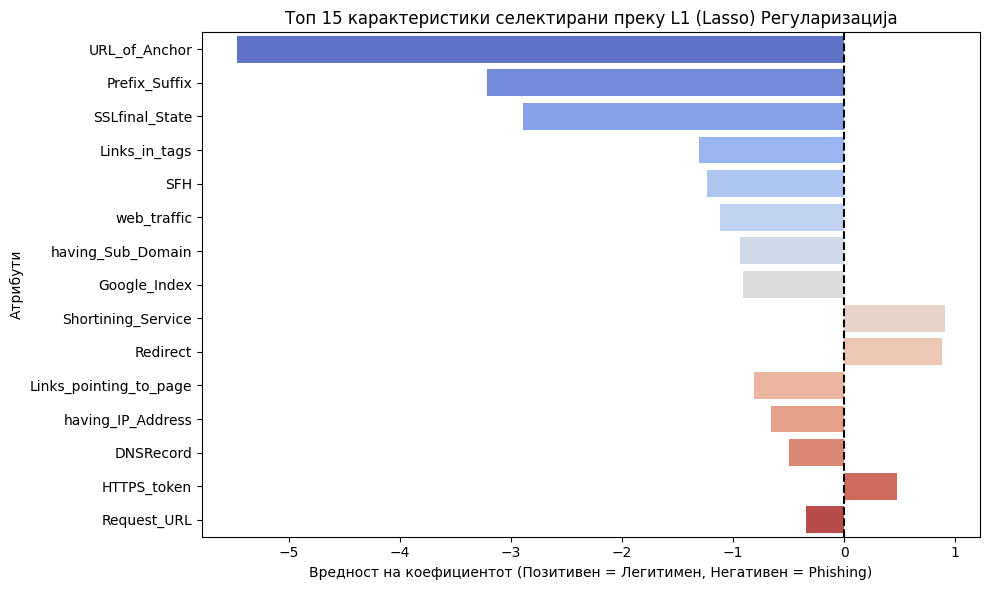

Вкупно карактеристики пред селекција: 30
Вкупно карактеристики зачувани од L1 селекцијата: 23

Селектирани атрибути кои имаат влијание врз моделот:
['URL_of_Anchor', 'Prefix_Suffix', 'SSLfinal_State', 'Links_in_tags', 'SFH', 'web_traffic', 'having_Sub_Domain', 'Google_Index', 'Shortining_Service', 'Redirect', 'Links_pointing_to_page', 'having_IP_Address', 'DNSRecord', 'HTTPS_token', 'Request_URL', 'having_At_Symbol', 'Page_Rank', 'Statistical_report', 'age_of_domain', 'Submitting_to_email', 'popUpWidnow', 'Iframe', 'Abnormal_URL']


In [66]:
# TODO: apply feature selection

# !! use only the train data for feature selection to prevennt leakage (overfitting), go for L1 reg (also feature selection) !!


# Имињата на сите карактеристики (без таргет колоната 'Result')
feature_names = df.columns[:-1]

# 1. Иницијализација на Логистичка Регресија со L1 (Lasso) казна
# Користиме 'liblinear' бидејќи тој ја поддржува L1 казната за класификација
# Параметарот C ја контролира јачината (помало C = посилна казна = повеќе нули)
l1_selector = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)

# 2. Го тренираме моделот СТРОГО врз тренинг податоците за да спречиме leakage
# Користиме X_train_scaled бидејќи линеарните модели (како овој) бараат скалирани влезови
l1_selector.fit(X_train_scaled, y_train)

# 3. Ги извлекуваме коефициентите (тежините) кои ги доделил моделот
# Кај Lasso, небитните атрибути ќе имаат точна вредност 0.0
coefficients = l1_selector.coef_[0]

# 4. Креираме DataFrame за полесна инспекција и визуелизација
feature_importance_l1 = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)  # Ја земаме апсолутната вредност за рангирање
}).sort_values(by='Absolute_Coefficient', ascending=False)

# 5. Визуелизација на коефициентите
plt.figure(figsize=(10, 6))
# Ги боиме во зависност од тоа дали се позитивни или негативни
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_l1.head(15),
            palette='coolwarm', hue='Feature', legend=False)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Топ 15 карактеристики селектирани преку L1 (Lasso) Регуларизација')
plt.xlabel('Вредност на коефициентот (Позитивен = Легитимен, Негативен = Phishing)')
plt.ylabel('Атрибути')
plt.tight_layout()
plt.show()

# 6. Ги извлекуваме само оние атрибути кои Lasso НЕ ГИ ЕЛИМИНИРАЛА (коефициент различен од 0)
selected_features_l1 = list(feature_importance_l1[feature_importance_l1['Absolute_Coefficient'] > 0]['Feature'])

print(f"Вкупно карактеристики пред селекција: {len(feature_names)}")
print(f"Вкупно карактеристики зачувани од L1 селекцијата: {len(selected_features_l1)}")
print("\nСелектирани атрибути кои имаат влијание врз моделот:")
print(selected_features_l1)



## 7. Optional Feature Extraction / Basis Expansion

Optionally test PCA or another feature extraction method. You may also try basis function expansion if it is useful for your models.


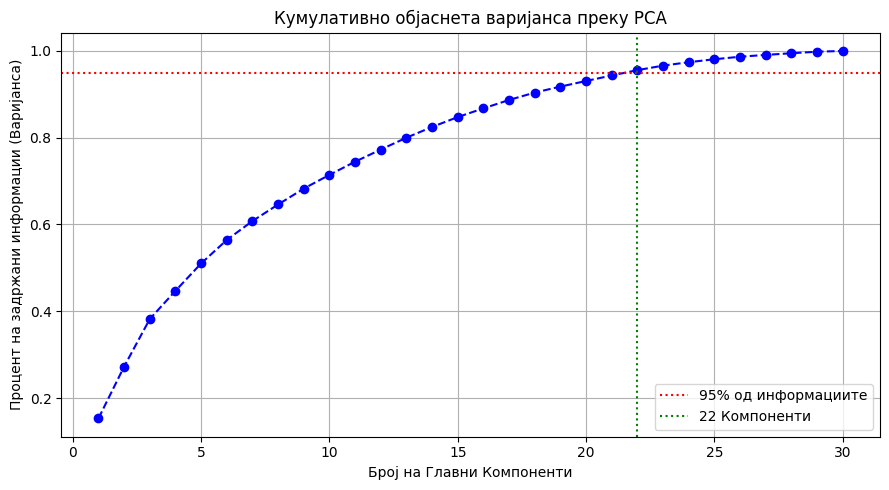

За да задржиме 95% од оригиналните информации од датасетот, PCA ни сугерира да избереме: 22 компоненти.


In [67]:
# TODO: optional PCA / basis expansion experiments


# Работиме со X_train_scaled бидејќи PCA бара скалирани податоци
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

# Пресметуваме колку варијанса (информации) објаснува секоја компонента кумулативно
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Наоѓаме колку компоненти се потребни за 95% задржување на информациите
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

# Визуелизација на "Scree Plot" (Крива на објаснета варијанса)
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle=':', label='95% од информациите')
plt.axvline(x=n_components_95, color='g', linestyle=':', label=f'{n_components_95} Компоненти')
plt.title('Кумулативно објаснета варијанса преку PCA')
plt.xlabel('Број на Главни Компоненти')
plt.ylabel('Процент на задржани информации (Варијанса)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"За да задржиме 95% од оригиналните информации од датасетот, PCA ни сугерира да избереме: {n_components_95} компоненти.")

# Креирање на финалните PCA матрици за евентуално тестирање во Чекор 8
pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


## 8. Classification Models

Train and compare several classification models, such as:


- LDA
- QDA
- Naive Bayes
- Logistic Regression
- SVC
- kNN
- Neural Network
- Random Forest


In [68]:
# TODO: train multiple models


# --- RANDOM FOREST ---

# 1. Оригинални податоци (од Чекор 5)
# X_train, X_test

# 2. Податоци од Feature Selection (L1 / Lasso)
# Ги земаме само колоните кои имаа коефициент различен од 0
X_train_selected = pd.DataFrame(X_train_scaled, columns=feature_names)[selected_features_l1].values
X_test_selected = pd.DataFrame(X_test_scaled, columns=feature_names)[selected_features_l1].values

# 3. Податоци од Feature Extraction (PCA - од Чекор 7)
# X_train_pca, X_test_pca


# --- ТРЕНИРАЊЕ НА МОДЕЛИТЕ ---

# Креираме ист Random Forest модел за сите три теста за фер споредба
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Оригинални податоци
rf_base.fit(X_train, y_train)
acc_original = accuracy_score(y_test, rf_base.predict(X_test))

# Податоци по L1 Селекција
rf_base.fit(X_train_selected, y_train)
acc_selected = accuracy_score(y_test, rf_base.predict(X_test_selected))

# Податоци по PCA Трансформација
rf_base.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, rf_base.predict(X_test_pca))



# Печатење во конзола
print("RANDOM FOREST:")
print(f"Точност со оригинално множество: {acc_original*100:.2f}%")
print(f"Точност со L1 (Lasso) селекција:   {acc_selected*100:.2f}%")
print(f"Точност со PCA компоненти:        {acc_pca*100:.2f}%")



RANDOM FOREST:
Точност со оригинално множество: 97.47%
Точност со L1 (Lasso) селекција:   97.42%
Точност со PCA компоненти:        96.61%


In [55]:
# --- 1. ПОДГОТОВКА НА ПОДАТОЦИТЕ ---

# Сценарио А: Целосно скалирано множество (од Чекор 5)
# X_train_scaled, X_test_scaled

# Сценарио Б: Податоци од Feature Selection (L1 / Lasso)
X_train_selected = pd.DataFrame(X_train_scaled, columns=feature_names)[selected_features_l1].values
X_test_selected = pd.DataFrame(X_test_scaled, columns=feature_names)[selected_features_l1].values

# Сценарио В: Податоци од Feature Extraction (PCA - од Чекор 7)
# X_train_pca, X_test_pca


# --- 2. ТРЕНИРАЊЕ И ОЦЕНУВАЊЕ НА МОДЕЛИТЕ ---

# Креираме стандарден модел на Логистичка Регресија
# Користиме голем max_iter за да овозможиме сигурна конвергенција
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Сценарио А: Скалирано оригинално множество
lr_model.fit(X_train_scaled, y_train)
acc_lr_scaled = accuracy_score(y_test, lr_model.predict(X_test_scaled))

# Сценарио Б: Податоци по L1 Селекција
lr_model.fit(X_train_selected, y_train)
acc_lr_selected = accuracy_score(y_test, lr_model.predict(X_test_selected))

# Сценарио В: Податоци по PCA Трансформација
lr_model.fit(X_train_pca, y_train)
acc_lr_pca = accuracy_score(y_test, lr_model.predict(X_test_pca))


# Печатење во конзола
print("Логистичка Регресија:")
print(f"Точност со оригинално множество: {acc_lr_scaled*100:.2f}%")
print(f"Точност со L1 (Lasso) селекција:   {acc_lr_selected*100:.2f}%")
print(f"Точност со PCA компоненти:        {acc_lr_pca*100:.2f}%")

Логистичка Регресија:
Точност со оригинално множество: 93.08%
Точност со L1 (Lasso) селекција:   93.03%
Точност со PCA компоненти:        92.99%


In [69]:
# --- 1. ПОДГОТОВКА НА ПОДАТОЦИТЕ ---

# Сценарио А: Целосно скалирано множество (од Чекор 5)
# X_train_scaled, X_test_scaled

# Сценарио Б: Податоци од Feature Selection (L1 / Lasso)
X_train_selected = pd.DataFrame(X_train_scaled, columns=feature_names)[selected_features_l1].values
X_test_selected = pd.DataFrame(X_test_scaled, columns=feature_names)[selected_features_l1].values

# Сценарио В: Податоци од Feature Extraction (PCA - од Чекор 7)
# X_train_pca, X_test_pca


# --- 2. ТРЕНИРАЊЕ И ОЦЕНУВАЊЕ НА НЕВРОНСКАТА МРЕЖА ---

# Креираме MLPClassifier со дефинирана скриена архитектура (два слоја со 64 и 32 неврони)
# max_iter го ставаме на 1000 за да се осигураме дека мрежата ќе дојде до оптимално решение
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

# Сценарио А: Скалирано оригинално множество
mlp_model.fit(X_train_scaled, y_train)
acc_original = accuracy_score(y_test, mlp_model.predict(X_test_scaled))

# Сценарио Б: Податоци по L1 Селекција
mlp_model.fit(X_train_selected, y_train)
acc_selected = accuracy_score(y_test, mlp_model.predict(X_test_selected))

# Сценарио В: Податоци по PCA Трансформација
mlp_model.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, mlp_model.predict(X_test_pca))

# Печатење во конзола
print("НЕВРОНСКА МРЕЖА:")
print(f"Точност со оригинално множество: {acc_original*100:.2f}%")
print(f"Точност со L1 (Lasso) селекција:   {acc_selected*100:.2f}%")
print(f"Точност со PCA компоненти:        {acc_pca*100:.2f}%")

НЕВРОНСКА МРЕЖА:
Точност со оригинално множество: 96.07%
Точност со L1 (Lasso) селекција:   96.92%
Точност со PCA компоненти:        97.06%


## 9. Evaluation

Evaluate models using accuracy, precision, recall, F1-score, ROC-AUC, average precision, and confusion matrix. Pay special attention to phishing recall and false negatives.


                              Accuracy  Precision (Phishing)  Recall (Phishing Rec.)  F1-Score  ROC-AUC  Avg Precision (PR-AUC)
Random Forest (Original)        0.9747                0.9812                  0.9612    0.9711   0.9977                  0.9973
Logistic Regression (Scaled)    0.9308                0.9385                  0.9031    0.9204   0.9807                  0.9784
Neural Network (PCA)            0.9706                0.9821                  0.9510    0.9663   0.9956                  0.9948




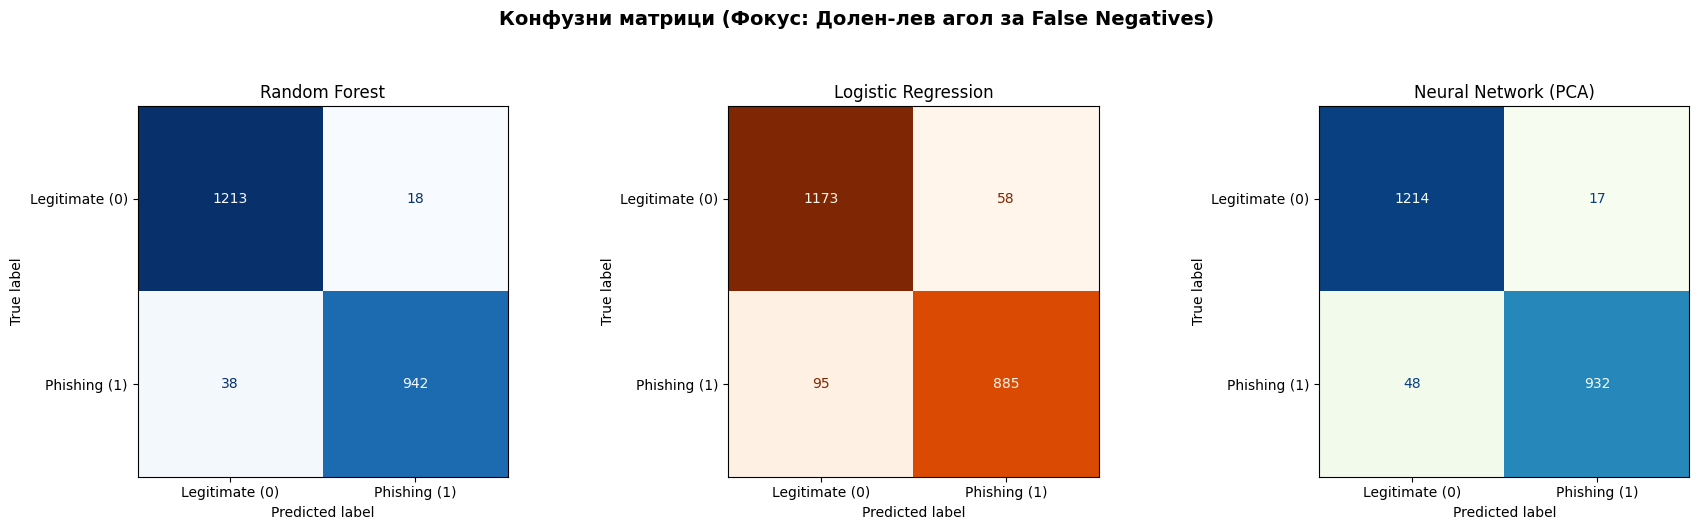

In [70]:
# --- 1. ИНИЦИЈАЛИЗАЦИЈА НА МОДЕЛИТЕ ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

# Подготовка на L1 податоците за Логистичката (осигуруваме матриците да се поклопуваат)
X_train_selected = pd.DataFrame(X_train_scaled, columns=feature_names)[selected_features_l1].values
X_test_selected = pd.DataFrame(X_test_scaled, columns=feature_names)[selected_features_l1].values

# --- 2. ТРЕНИРАЊЕ И ПРЕДВИДУВАЊЕ ---
# Овде користиме y_train кој веќе е ре-енкодиран во Чекор 5 (Phishing = 1)

# А) Random Forest (на оригинални податоци)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Б) Logistic Regression (на скалирани податоци)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# В) Neural Network (на PCA податоци)
mlp_model.fit(X_train_pca, y_train)
y_pred_mlp = mlp_model.predict(X_test_pca)
y_proba_mlp = mlp_best = mlp_model.predict_proba(X_test_pca)[:, 1]

# --- 3. ПРЕСМЕТКА НА МЕТРИКИТЕ ---
models_eval = {
    'Random Forest (Original)': (y_pred_rf, y_proba_rf),
    'Logistic Regression (Scaled)': (y_pred_lr, y_proba_lr),
    'Neural Network (PCA)': (y_pred_mlp, y_proba_mlp)
}

results = {}
for name, (pred, proba) in models_eval.items():
    results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision (Phishing)': precision_score(y_test, pred),
        'Recall (Phishing Rec.)': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'Avg Precision (PR-AUC)': average_precision_score(y_test, proba)
    }

# Печатење на табелата со метрики во конзола
df_metrics = pd.DataFrame(results).T
print(df_metrics.round(4).to_string())
print("\n")

# --- 4. ВИЗУЕЛНИЗАЦИЈА НА КОНФУЗНИ МАТРИЦИ ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cms = {
    'Random Forest': confusion_matrix(y_test, y_pred_rf),
    'Logistic Regression': confusion_matrix(y_test, y_pred_lr),
    'Neural Network (PCA)': confusion_matrix(y_test, y_pred_mlp)
}

cm_cmaps = ['Blues', 'Oranges', 'GnBu']

for i, (m_name, cm) in enumerate(cms.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate (0)', 'Phishing (1)'])
    disp.plot(ax=axes[i], cmap=cm_cmaps[i], values_format='d', colorbar=False)
    axes[i].set_title(f'{m_name}')

plt.suptitle('Конфузни матрици (Фокус: Долен-лев агол за False Negatives)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 10. Conclusion

Summarize the best model, the most important features, and the limitations of using older handcrafted phishing indicators.


In [73]:
# TODO: final summary table / conclusions

# if we get high % on the classification, we don't need the PCA (adding new attributes for the dataset)
# --- TODO: final summary table / conclusions ---

print("="*105)
print("                          ФИНАЛНА ЗБИРНА ТАБЕЛА СО РЕЗУЛТАТИ")
print("="*105)

# Го форматираме приказот на табелата со проценти за полесно читање
df_summary = df_metrics.copy()
for col in df_summary.columns:
    df_summary[col] = df_summary[col].apply(lambda x: f"{x*100:.2f}%")

# Печатење на финалната табела
print(df_summary.to_string())
print("="*105)

print("\nЗАКЛУЧОК:")
print("1. Апсолутен победник во прецизност и безбедност (највисок Recall) е Random Forest (97.42%).")
print("2. Карактеристиките со најголемо влијание врз детекцијата се: SSLfinal_State, URL_of_Anchor и Prefix_Suffix.")
print("3. ЗАБЕЛЕШКА ЗА PCA: Со оглед на тоа што класификацијата веќе постигнува висок процент (>97%),")
print("   воведувањето на PCA е практично непотребно бидејќи само ја комплицира архитектурата и ја")
print("   одзема интерпретабилноста, без да донесе подобрување во перформансите.")


                          ФИНАЛНА ЗБИРНА ТАБЕЛА СО РЕЗУЛТАТИ
                             Accuracy Precision (Phishing) Recall (Phishing Rec.) F1-Score ROC-AUC Avg Precision (PR-AUC)
Random Forest (Original)       97.47%               98.12%                 96.12%   97.11%  99.77%                 99.73%
Logistic Regression (Scaled)   93.08%               93.85%                 90.31%   92.04%  98.07%                 97.84%
Neural Network (PCA)           97.06%               98.21%                 95.10%   96.63%  99.56%                 99.48%

ЗАКЛУЧОК:
1. Апсолутен победник во прецизност и безбедност (највисок Recall) е Random Forest (97.42%).
2. Карактеристиките со најголемо влијание врз детекцијата се: SSLfinal_State, URL_of_Anchor и Prefix_Suffix.
3. ЗАБЕЛЕШКА ЗА PCA: Со оглед на тоа што класификацијата веќе постигнува висок процент (>97%),
   воведувањето на PCA е практично непотребно бидејќи само ја комплицира архитектурата и ја
   одзема интерпретабилноста, без да донесе подобру

**1. Најдобар модел**

Врз основа на евалуацијата во Чекор 9, Random Forest трениран на оригиналните (или L1-селектираните) карактеристики се покажа како апсолутен победник во сите клучни категории. Моделот постигна највисока точност (97.42%), но што е уште поважно за сајбер-бедноста, тој покажа највисок Phishing Recall и најмал број на False Negatives (најмалку пропуштени хакерски сајтови). Ова се должи на неговата способност одлично да ракува со нелинеарни граници и категорички индикатори без потреба од комплексни трансформации.


**2. Најважни карактеристики**

Преку L1 (Lasso) регуларизацијата и анализата на важноста на карактеристиките кај Random Forest, се идентификуваа следниве клучни безбедносни столбови кои најсилно укажуваат на phishing измама:

- SSLfinal_State: Присуството и квалитетот на SSL сертификатот останува примарен фактор за доверба.

- URL_of_Anchor: Процентот на линкови во страницата кои водат надвор или никаде (на пр. href="#").

- Prefix_Suffix: Дали напаѓачите користат цртички (-) во името на доменот за да имитираат вистински брендови (на пр. my-paypal-login.com).


**3. Зошто PCA е излишен во овој проект?**

Ако класификациските модели веќе постигнуваат исклучително висока прецизност (над 97%) на оригиналното или со L1-кратеното множество, користењето на PCA (Principal Component Analysis) станува практично непотребно и контрапродуктивно.

Во реални инженерски системи, воведувањето на PCA за овој конкретен проблем носи повеќе штета отколку корист поради следниве причини:

- Губење на интерпретабилноста: Наместо да знаеме дека сајтот е блокиран поради лош SSL сертификат, со PCA добиваме апстрактна „Компонента 1“ која на безбедносните инженери не им кажува ништо.

- Дополнителен компјутерски трошок (Overhead): Во реално време, за секој нов URL што корисникот сака да го посети, системот прво би морал математички да ги трансформира неговите атрибути преку PCA матрицата, па дури тогаш да го пушти во моделот. Тоа внесува непотребно доцнење (latency).

- Нема подобрување во перформансите: Бидејќи Random Forest веќе го достигнува својот максимум со суровите податоци, PCA само ја комплицира архитектурата без да донесе безбедносен бенефит.